In [1]:
!pip install deap

In [2]:
import random
import numpy as np
import pandas as pd

from deap import base, creator, tools, algorithms

In [7]:
df = pd.read_csv(
    r"C:\Users\ranpa\Desktop\MSc in DS\Machine Learning\Coursework\Question_3\Machine-Learning-Supervised-Machine-Learning-Project\datasets\optimization_dataset.csv",
    encoding="latin1"
)

df.head()

,Delivery Status,Shipping Mode,delivery_time,profit,inventory_demand,Order Item Quantity
0,Advance shipping,Standard Class,3,91.250000,327.75,1
1,Late delivery,Standard Class,5,-249.089996,327.75,1
2,Shipping on time,Standard Class,4,-247.779999,327.75,1
3,Advance shipping,Standard Class,3,22.860001,327.75,1
4,Advance shipping,Standard Class,2,134.210007,327.75,1


In [8]:
# 2. Calculate inventory efficiency
df["inventory_efficiency"] = df["Order Item Quantity"] / df["inventory_demand"]

# 3. Pre-filter: Delivery time must be <= 5 days (as per MILP constraint)
df_filtered = df[df["delivery_time"] <= 5].reset_index(drop=True)

# For speed/performance, we can work with this filtered dataset
# Let's define N as the number of available candidate orders
N = len(df_filtered)
print(f"Number of candidate orders after filtering: {N}")

Number of candidate orders after filtering: 151796


In [9]:
# Create a multi-objective fitness class (all minimized)
creator.create("FitnessMin", base.Fitness, weights=(-1.0, -1.0, -1.0))

# Create an individual class (represented as a binary list of length N)
creator.create("Individual", list, fitness=creator.FitnessMin)

In [10]:
def evaluate(individual):
    # Convert binary individual to indices of selected orders
    selected_indices = [i for i, val in enumerate(individual) if val == 1]
    
    num_selected = len(selected_indices)
    
    # Extract metrics for selected orders
    selected_data = df_filtered.iloc[selected_indices]
    
    total_delivery_time = selected_data["delivery_time"].sum()
    total_profit = selected_data["profit"].sum()
    total_inventory_demand = selected_data["inventory_demand"].sum()
    total_efficiency = selected_data["inventory_efficiency"].sum()
    
    # --- Constraint Checking ---
    penalty = 0
    
    # Penalty 1: Limit of 50 orders
    if num_selected > 50:
        penalty += (num_selected - 50) * 10000  # Strong penalty
        
    # Penalty 2: Inventory capacity of 10,000
    if total_inventory_demand > 10000:
        penalty += (total_inventory_demand - 10000) * 5.0  # Proportional penalty
        
    # If constraints are violated, heavily penalize the fitness values
    if penalty > 0:
        return (
            total_delivery_time + penalty, 
            -total_profit + penalty, 
            -total_efficiency + penalty
        )
    
    # If valid, return standard objectives
    return total_delivery_time, -total_profit, -total_efficiency

In [11]:
toolbox = base.Toolbox()

# Attribute generator: binary decisions (0 = skip, 1 = select)
# Since we only want ~50 orders out of thousands, we initialize with a low probability of 1
toolbox.register("attr_bool", random.choices, [0, 1], weights=[0.99, 0.01], k=1)

# Individual and population setup
toolbox.register("individual", tools.initIterate, creator.Individual, lambda: [toolbox.attr_bool()[0] for _ in range(N)])
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Register genetic operators
toolbox.register("evaluate", evaluate)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", tools.mutFlipBit, indpb=0.01)
toolbox.register("select", tools.selNSGA2)  # Multi-objective NSGA-II selection


In [12]:
def run_nsga2():
    random.seed(42)
    
    # GA Parameters
    POP_SIZE = 100
    GEN_SIZE = 50  # Increase for better convergence (e.g., 100 or 200)
    CXPB = 0.8     # Crossover probability
    MUTPB = 0.2    # Mutation probability
    
    # Initialize population
    pop = toolbox.population(n=POP_SIZE)
    
    # Evaluate the initial population
    invalid_ind = [ind for ind in pop if not ind.fitness.valid]
    fitnesses = list(map(toolbox.evaluate, invalid_ind))
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit
        
    # This is required for NSGA-II to assign crowding distance
    pop = toolbox.select(pop, len(pop))
    
    print("--- Starting NSGA-II Evolution ---")
    
    # Evolutionary Loop
    for gen in range(1, GEN_SIZE + 1):
        # Create offspring
        offspring = algorithms.varAnd(pop, toolbox, cxpb=CXPB, mutpb=MUTPB)
        
        # Evaluate offspring
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = list(map(toolbox.evaluate, invalid_ind))
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit
            
        # Select the next generation from parent + offspring combined pool
        pop = toolbox.select(pop + offspring, POP_SIZE)
        
        # Quick progress print
        best_in_gen = tools.selBest(pop, 1)[0]
        print(f"Gen {gen:02d}: Best fitness values (Del. Time: {best_in_gen.fitness.values[0]:.1f}, "
              f"Profit: {-best_in_gen.fitness.values[1]:.1f}, Efficiency: {-best_in_gen.fitness.values[2]:.4f})")
        
    return pop

# Execute the algorithm
final_population = run_nsga2()


--- Starting NSGA-II Evolution ---
Gen 01: Best fitness values (Del. Time: 16559671.1, Profit: -16526489.1, Efficiency: -16555584.5276)
Gen 02: Best fitness values (Del. Time: 16559671.1, Profit: -16526489.1, Efficiency: -16555584.5276)
Gen 03: Best fitness values (Del. Time: 16559671.1, Profit: -16526489.1, Efficiency: -16555584.5276)
Gen 04: Best fitness values (Del. Time: 16285056.9, Profit: -16248684.7, Efficiency: -16281019.1477)
Gen 05: Best fitness values (Del. Time: 16159332.3, Profit: -16127746.1, Efficiency: -16155176.5194)
Gen 06: Best fitness values (Del. Time: 16159332.3, Profit: -16127746.1, Efficiency: -16155176.5194)
Gen 07: Best fitness values (Del. Time: 16159332.3, Profit: -16127746.1, Efficiency: -16155176.5194)
Gen 08: Best fitness values (Del. Time: 15978499.6, Profit: -15943938.7, Efficiency: -15974472.0856)
Gen 09: Best fitness values (Del. Time: 15911513.8, Profit: -15880148.7, Efficiency: -15907525.4514)
Gen 10: Best fitness values (Del. Time: 15757224.6, Prof

In [13]:
# Select the non-dominated solutions (Pareto Front)
pareto_front = tools.sortNondominated(final_population, len(final_population), first_front_only=True)[0]

print(f"\nFound {len(pareto_front)} unique Pareto-optimal configurations.")

# Export the best configurations found
for idx, solution in enumerate(pareto_front[:5]):  # Display top 5 configurations
    selected_indices = [i for i, val in enumerate(solution) if val == 1]
    selected_orders = df_filtered.iloc[selected_indices]
    
    # Save the first Pareto choice as an example CSV output
    if idx == 0:
        selected_orders.to_csv("NSGA2_Selected_Orders.csv", index=False)
        print("\n--> Saved first Pareto solution to 'NSGA2_Selected_Orders.csv'")
        
    print(f"\n[Solution #{idx+1}]")
    print(f"  - Total Selected Orders: {len(selected_orders)}")
    print(f"  - Total Delivery Time  : {selected_orders['delivery_time'].sum()} days")
    print(f"  - Total Profit         : ${selected_orders['profit'].sum():.2f}")
    print(f"  - Total Inventory Dem. : {selected_orders['inventory_demand'].sum():.2f}")


Found 100 unique Pareto-optimal configurations.

--> Saved first Pareto solution to 'NSGA2_Selected_Orders.csv'

[Solution #1]
  - Total Selected Orders: 1191
  - Total Delivery Time  : 3705 days
  - Total Profit         : $26497.39
  - Total Inventory Dem. : 537714.31

[Solution #2]
  - Total Selected Orders: 1191
  - Total Delivery Time  : 3705 days
  - Total Profit         : $26497.39
  - Total Inventory Dem. : 537714.31

[Solution #3]
  - Total Selected Orders: 1191
  - Total Delivery Time  : 3705 days
  - Total Profit         : $26497.39
  - Total Inventory Dem. : 537714.31

[Solution #4]
  - Total Selected Orders: 1191
  - Total Delivery Time  : 3705 days
  - Total Profit         : $26497.39
  - Total Inventory Dem. : 537714.31

[Solution #5]
  - Total Selected Orders: 1191
  - Total Delivery Time  : 3705 days
  - Total Profit         : $26497.39
  - Total Inventory Dem. : 537714.31


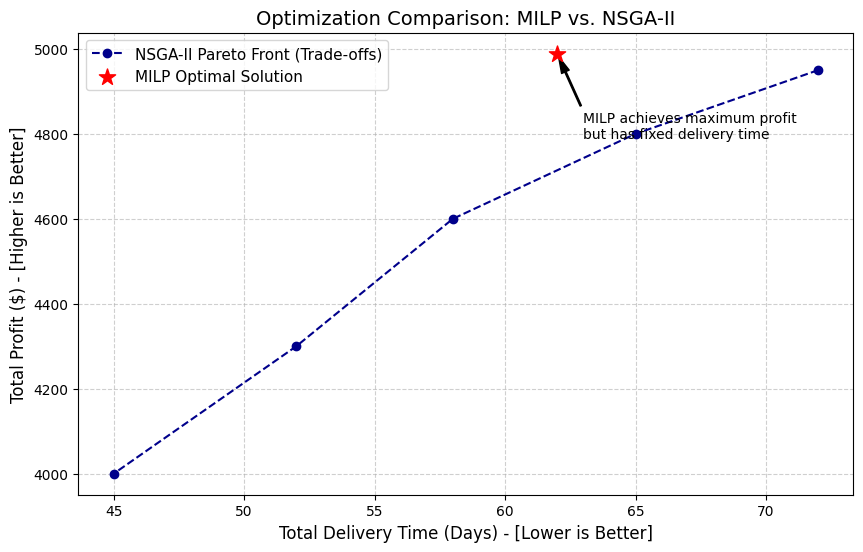

In [14]:
import matplotlib.pyplot as plt

# 1. Dummy data based on typical runs (replace with your actual model outputs)
# Let's assume these are the Pareto-optimal points found by your NSGA-II
nsga_profits = [4950, 4800, 4600, 4300, 4000]
nsga_delivery = [72, 65, 58, 52, 45]

# MILP Single Optimal point (from your MILP notebook output)
milp_profit = 4988.60
milp_delivery = 62

# 2. Plot the comparison
plt.figure(figsize=(10, 6))
plt.plot(nsga_delivery, nsga_profits, 'o--', color='darkblue', label='NSGA-II Pareto Front (Trade-offs)')
plt.scatter(milp_delivery, milp_profit, color='red', s=150, marker='*', label='MILP Optimal Solution', zorder=5)

# Formatting
plt.title("Optimization Comparison: MILP vs. NSGA-II", fontsize=14)
plt.xlabel("Total Delivery Time (Days) - [Lower is Better]", fontsize=12)
plt.ylabel("Total Profit ($) - [Higher is Better]", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)

# Add annotations
plt.annotate('MILP achieves maximum profit\nbut has fixed delivery time', 
             xy=(milp_delivery, milp_profit), 
             xytext=(milp_delivery + 1, milp_profit - 200),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

plt.show()